In [1]:
import sys
import os

project_root = os.path.abspath('..')

if project_root not in sys.path:
    sys.path.append(project_root)

ULA simulation

In [2]:
from src.simulator import ULASimulator

In [3]:
sim = ULASimulator(M=8, fc=2.4e9)

X, A, S = sim.generate_signal(sources_theta=[20, -40], snr_db=10, n_snapshots=100)

print(f"Size of matrix X (M antennas x N snapshots): {X.shape}")

Size of matrix X (M antennas x N snapshots): (8, 100)


Delay-and-Sum testing

In [4]:
from src.algorithms import Beamformer
import numpy as np
import matplotlib.pyplot as plt

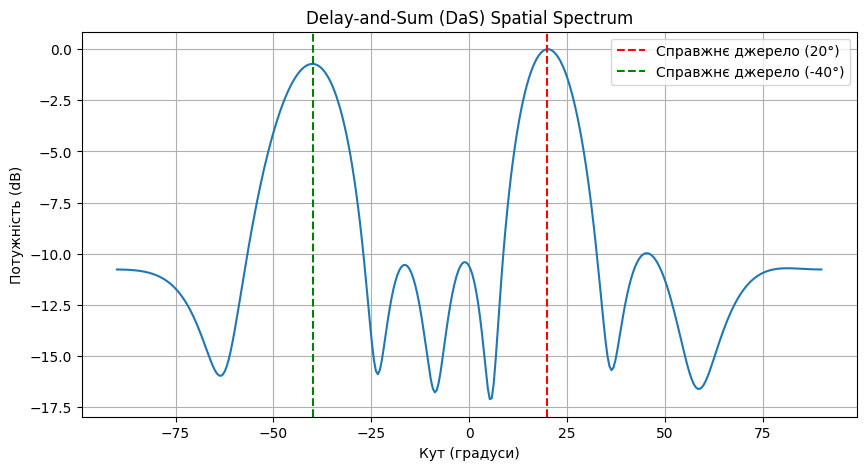

In [5]:
bf = Beamformer(sim)
R = bf.compute_covariance(X)

scan_angles = np.linspace(-90, 90, 360) 
spectrum = bf.run_das(R, scan_angles)

spectrum_db = 10 * np.log10(spectrum / np.max(spectrum))

plt.figure(figsize=(10, 5))
plt.plot(scan_angles, spectrum_db)
plt.axvline(20, color='r', linestyle='--', label='Справжнє джерело (20°)')
plt.axvline(-40, color='g', linestyle='--', label='Справжнє джерело (-40°)')
plt.title("Delay-and-Sum (DaS) Spatial Spectrum")
plt.xlabel("Кут (градуси)")
plt.ylabel("Потужність (dB)")
plt.legend()
plt.grid(True)
plt.show()

Comparison DaS vs MVDR

In [9]:
angles = [10, 15] 
sim = ULASimulator(M=10, fc=2.4e9)
X, _, _ = sim.generate_signal(sources_theta=angles, snr_db=20, n_snapshots=500)

bf = Beamformer(sim)
R = bf.compute_covariance(X)
scan_angles = np.linspace(-90, 90, 500)

spectrum_das = bf.run_das(R, scan_angles)
spectrum_mvdr = bf.run_mvdr(R, scan_angles)

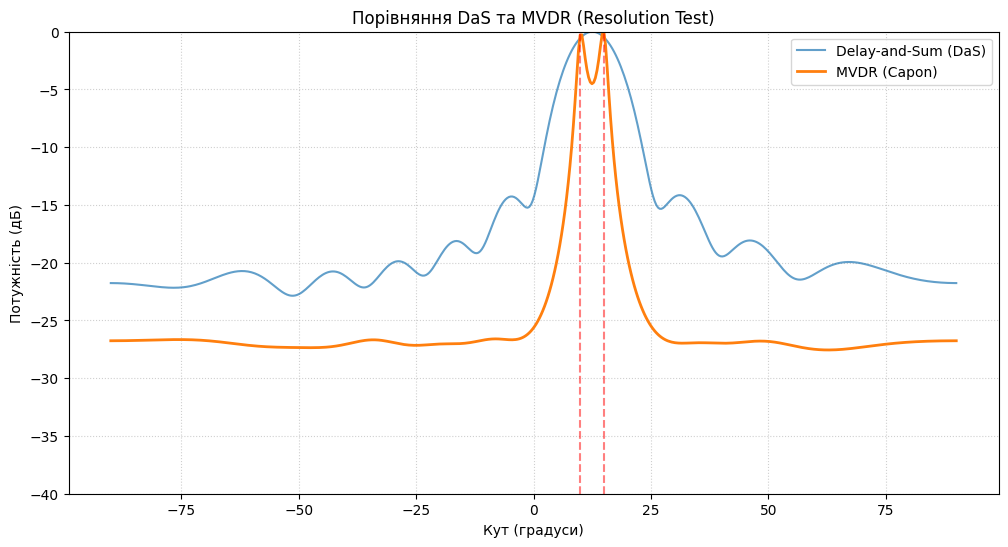

In [10]:
def to_db(s):
    return 10 * np.log10(s / np.max(s))

plt.figure(figsize=(12, 6))
plt.plot(scan_angles, to_db(spectrum_das), label='Delay-and-Sum (DaS)', alpha=0.7)
plt.plot(scan_angles, to_db(spectrum_mvdr), label='MVDR (Capon)', linewidth=2)

for a in angles:
    plt.axvline(a, color='red', linestyle='--', alpha=0.5)

plt.title("Порівняння DaS та MVDR (Resolution Test)")
plt.xlabel("Кут (градуси)")
plt.ylabel("Потужність (дБ)")
plt.ylim([-40, 0])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()